In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

import mne 
from mne.datasets import eegbci
from mne.io import read_raw_edf, concatenate_raws

from pyriemann.estimation import Covariances 
from pyriemann.utils.mean import mean_riemann
from pyriemann.utils.distance import distance_riemann

from sklearn.metrics import roc_curve,auc 

In [2]:
subjects = list(range(1,10))
runs = [4,8,12]

In [3]:
def load_subject_data(subject):
    runs = [3,8,12]

    files=eegbci.load_data(subject,runs)
    raws = [read_raw_edf (file, preload=True, verbose = False) for file in files]
    raw = concatenate_raws(raws)

    eegbci.standardize(raw)

    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage, on_missing="ignore")

    raw.filter(8., 30., fir_design= "firwin", verbose=False)

    events, event_id = mne.events_from_annotations(raw, verbose = False)

    selected_event_id = {
        "left_hand": event_id["T1"],
        "right_hand": event_id["T2"]
    }

    epochs = mne.Epochs (
    raw,
    events,
    event_id=selected_event_id,
    tmin=1.,
    tmax=4.0,
    baseline=None,
    preload=True,
    verbose=False
)

    X = epochs.get_data()
    y_task = epochs.events[:,-1]
    y_task = np.where(y_task == selected_event_id["left_hand"], 0, 1)

    y_subject = np.full (len(X), subject )

    return X, y_task, y_subject

In [4]:
X, y_task, y_subject = load_subject_data(1)

print("EEG data shape:", X.shape)
print("Task labels shape:", y_task.shape)
print("Subject labels shape:", y_subject.shape)

print("Task labels:", np.unique(y_task))
print("Subject labels:", np.unique(y_subject))

EEG data shape: (45, 64, 481)
Task labels shape: (45,)
Subject labels shape: (45,)
Task labels: [0 1]
Subject labels: [1]


In [5]:
all_X = []
all_y_task = []
all_y_subject = []

for subject in subjects:
    print(f"Loading subject {subject}...")
    
    X, y_task, y_subject = load_subject_data(subject)
    
    all_X.append(X)
    all_y_task.append(y_task)
    all_y_subject.append(y_subject)

X_all = np.concatenate(all_X, axis=0)
y_task_all = np.concatenate(all_y_task, axis=0)
y_subject_all = np.concatenate(all_y_subject, axis=0)

print("All EEG data shape:", X_all.shape)
print("All task labels shape:", y_task_all.shape)
print("All subject labels shape:", y_subject_all.shape)
print("Subjects:", np.unique(y_subject_all))

Loading subject 1...
Loading subject 2...
Loading subject 3...
Loading subject 4...
Loading subject 5...
Loading subject 6...
Loading subject 7...
Loading subject 8...
Loading subject 9...
All EEG data shape: (405, 64, 481)
All task labels shape: (405,)
All subject labels shape: (405,)
Subjects: [1 2 3 4 5 6 7 8 9]


In [6]:
cov_estimator = Covariances(estimator="oas")

cov_matrices = cov_estimator.fit_transform(X_all)

print("Covariance matrices shape:", cov_matrices.shape)

Covariance matrices shape: (405, 64, 64)


In [7]:
enrollment_templates = {}
test_covs = []
test_subjects = []

n_enroll = 20

for subject in subjects:
    subject_indices = np.where(y_subject_all == subject)[0]
    
    enroll_indices = subject_indices[:n_enroll]
    test_indices = subject_indices[n_enroll:]
    
    subject_enroll_covs = cov_matrices[enroll_indices]
    subject_test_covs = cov_matrices[test_indices]
    
    template = mean_riemann(subject_enroll_covs)
    
    enrollment_templates[subject] = template
    
    test_covs.append(subject_test_covs)
    test_subjects.append(y_subject_all[test_indices])

test_covs = np.concatenate(test_covs, axis=0)
test_subjects = np.concatenate(test_subjects, axis=0)

print("Number of enrolled subjects:", len(enrollment_templates))
print("Test covariance shape:", test_covs.shape)
print("Test subject labels shape:", test_subjects.shape)

Number of enrolled subjects: 9
Test covariance shape: (225, 64, 64)
Test subject labels shape: (225,)


In [8]:
auth_scores = []
auth_labels = []
claimed_subjects = []
true_subjects = []

for i, cov in enumerate(test_covs):
    true_subject = test_subjects[i]
    
    for claimed_subject, template in enrollment_templates.items():
        distance = distance_riemann(cov, template)
        
        auth_scores.append(-distance)
        auth_labels.append(1 if true_subject == claimed_subject else 0)
        claimed_subjects.append(claimed_subject)
        true_subjects.append(true_subject)

auth_scores = np.array(auth_scores)
auth_labels = np.array(auth_labels)
claimed_subjects = np.array(claimed_subjects)
true_subjects = np.array(true_subjects)

print("Authentication attempts:", len(auth_scores))
print("Genuine attempts:", np.sum(auth_labels == 1))
print("Impostor attempts:", np.sum(auth_labels == 0))

Authentication attempts: 2025
Genuine attempts: 225
Impostor attempts: 1800


In [9]:
fpr, tpr, thresholds = roc_curve(auth_labels, auth_scores)

roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.9999876543209877


In [10]:
fnr = 1 - tpr

eer_index = np.nanargmin(np.abs(fpr - fnr))
eer = (fpr[eer_index] + fnr[eer_index]) / 2
eer_threshold = thresholds[eer_index]

print("Equal Error Rate:", eer)
print("EER Threshold:", eer_threshold)

Equal Error Rate: 0.0036111111111111257
EER Threshold: -9.751191927462168


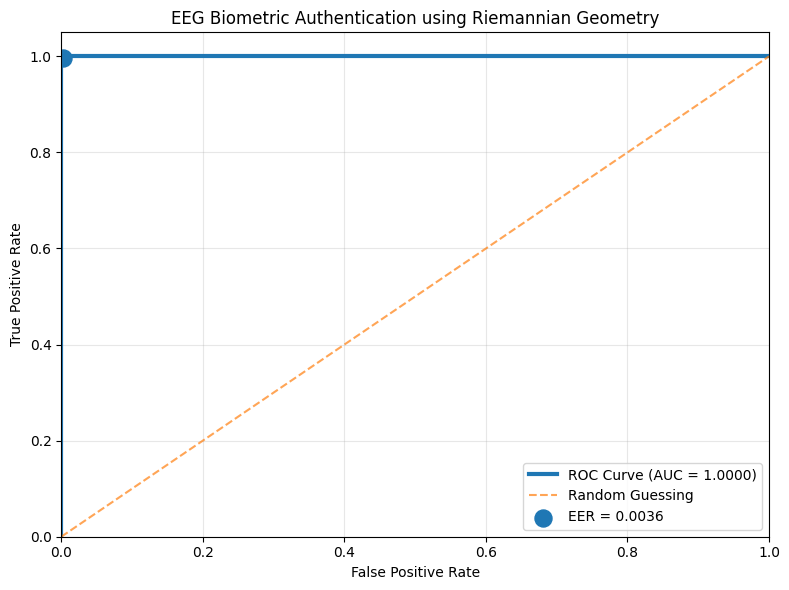

In [12]:
plt.figure(figsize=(8,6))

# ROC curve
plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    '--',
    alpha=0.7,
    label="Random Guessing"
)

# Equal Error Rate operating point
plt.scatter(
    fpr[eer_index],
    tpr[eer_index],
    s=150,
    label=f"EER = {eer:.4f}"
)

plt.xlim([0, 1])
plt.ylim([0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EEG Biometric Authentication using Riemannian Geometry")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

# IMPORTANT: save BEFORE show()
plt.savefig(
    "../figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()